In [ ]:
from fastai import *
import torch
import matplotlib.pyplot as plt
import numpy as np

# For interaction
from ipywidgets import interact

#### For Function Plotting and Interaction

In [2]:
def plot_function(f, title=None, min=-2.1, max=2.1, color='r', ylim=None):
    x = torch.linspace(min,max, 100)[:,None]
    if ylim: plt.ylim(ylim)
    plt.plot(x, f(x), color)
    if title is not None: plt.title(title)

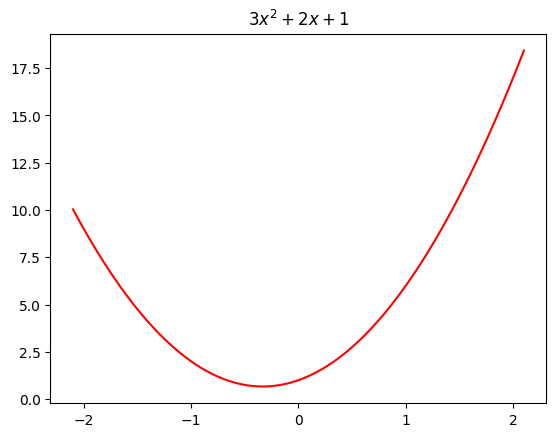

In [3]:
def f(x): return 3*x**2 + 2*x + 1
plot_function(f, "$3x^2 + 2x + 1$")

In [4]:
def quad(a, b, c, x): return a*x**2 + b*x + c

In [5]:
quad(3,2,1, 1.5)

10.75

In [6]:
from functools import partial
def mk_quad(a,b,c): return partial(quad, a,b,c)

In [7]:
f = mk_quad(3,2,1)
f(1.5)

10.75

In [8]:
from numpy.random import normal,seed,uniform
np.random.seed(42)
def noise(x, scale): return normal(scale=scale, size=x.shape)
def add_noise(x, mult, add): return x * (1+noise(x,mult)) + noise(x,add)

C:\Users\mores\AppData\Local\Temp\ipykernel_4896\683808164.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  def add_noise(x, mult, add): return x * (1+noise(x,mult)) + noise(x,add)


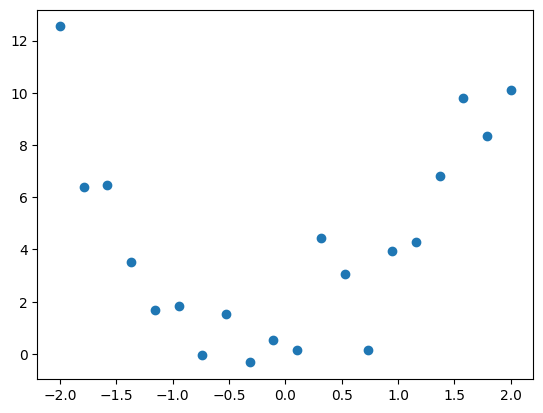

In [9]:
x = torch.linspace(-2, 2, steps=20)[:,None]
y = add_noise(f(x), 0.3, 1.5)
plt.scatter(x,y)

In [10]:
# from ipywidgets import interact
@interact(a=1.5, b=1.5, c=1.5)
def plot_quad(a, b, c):
    plt.scatter(x,y)
    plot_function(mk_quad(a,b,c), ylim=(-3,12))

interactive(children=(FloatSlider(value=1.5, description='a', max=4.5, min=-1.5), FloatSlider(value=1.5, descr…

In [11]:
def mse(preds, acts): return((preds-acts)**2).mean()

In [ ]:
# from ipywidgets import interact
@interact(a=1.5, b=1.5, c=1.5)
def plot_quad(a, b, c):
    plt.scatter(x,y)
    loss = mse(f(x), y)
    plot_function(mk_quad(a,b,c), ylim=(-3,12), title=f"MSE: {loss:.2f}")

interactive(children=(FloatSlider(value=1.5, description='a', max=4.5, min=-1.5), FloatSlider(value=1.5, descr…

#### For torch learning

In [3]:
help(torch.where)

Help on built-in function where in module torch:

where(...)
    where(condition, input, other, *, out=None) -> Tensor

    Return a tensor of elements selected from either :attr:`input` or :attr:`other`, depending on :attr:`condition`.

    The operation is defined as:

    .. math::
        \text{out}_i = \begin{cases}
            \text{input}_i & \text{if } \text{condition}_i \\
            \text{other}_i & \text{otherwise} \\
        \end{cases}

    .. note::
        The tensors :attr:`condition`, :attr:`input`, :attr:`other` must be :ref:`broadcastable <broadcasting-semantics>`.

    Arguments:
        condition (BoolTensor): When True (nonzero), yield input, otherwise yield other
        input (Tensor or Scalar): value (if :attr:`input` is a scalar) or values selected at indices
                              where :attr:`condition` is ``True``
        other (Tensor or Scalar): value (if :attr:`other` is a scalar) or values selected at indices
                              where 